# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get model results

In [6]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']

cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


(1440, 6)

In [77]:
# Path to results 
# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations

# match human pilot conditions
# model_name = 'word_task_standard_v08'
model_names = ['word_task_half_co_loc_v07']
# model_name = 'word_task_quarter_co_loc_v08'
# model_name = 'word_task_25p_loc_v07_LN_last_valid_time_no_affine'

# output_paths = list(Path(f"/om2/user/rphess/Auditory-Attention/binaural_eval/human_pilot_conds/{model_name}").glob("*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_distractor_language_2024/final_stim_manifest_w_cue_tg_lang_dists.pdpkl')

all_model_results = []

for model_name in model_names:
    if "v0" in model_name:
        output_paths = list(Path(f'unfamiliar_distractor/{model_name}').glob('*.csv'))
        print(len(output_paths))

    results_dfs = []

    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        # get language from name
        if 'english' in path.stem:
             df['distractor_language'] = 'english'   
        elif 'mandarin' in path.stem:
             df['distractor_language'] = 'mandarin'   
        elif 'dutch' in path.stem:
             df['distractor_language'] = 'dutch'   


        if 'clean' in path.stem:
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        
        # merge df's on indnex

        
        results_dfs.append(df.join(stim_manifest_df))

    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_results['sex_cond'] = model_results.apply(lambda row: 'Same sex distractor' if row['gender'] == row['distractor_gender'] else 'Different sex distractor', axis=1)

    # model_str = model_name_dict[model_name]
    # model_results['group'] = model_str

    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_name else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)

    all_model_results.append(model_results)

    
all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_results['confusions'] = (all_model_results['pred_word'] ==  all_model_results['distractor_word']).astype('int')

18


In [78]:
all_model_results.loc[all_model_results.snr == 'inf', 'snr'] = 6
all_model_results.loc[all_model_results.snr == 6, 'distractor_language'] = "no distractor"
all_model_results.snr = all_model_results.snr.astype('int')

In [79]:
all_model_results.columns

Index(['pred_word_int', 'true_word_int', 'accuracy', 'model',
       'distractor_language', 'snr', 'distractor_client_id',
       'distractor_corpus', 'distractor_gender', 'distractor_gender_int',
       'distractor_sr', 'distractor_src_fn', 'distractor_word', 'src_ix',
       'client_id', 'corpus', 'gender', 'gender_int', 'sr', 'src_fn', 'word',
       'cue_word', 'cue_src_ix', 'cue_client_id', 'cue_src_fn',
       'gender_cond_td', 'zh_distractor_client_id', 'zh_distractor_gender',
       'zh_distractor_src_fn', 'nl_distractor_client_id',
       'nl_distractor_gender', 'nl_distractor_src_fn', 'nl_distractor_corpus',
       'zh_distractor_corpus', 'signal_len_s', 'word_int',
       'distractor_word_int', 'sex_cond', 'pred_word', 'true_word',
       'confusions'],
      dtype='object')

In [80]:
# melted_results = pd.melt(results, id_vars=['snr', 'Distractor Sex', 'Distractor Playback'],
#         value_vars=['accuracy', 'confusions'],
#         value_name = 'hits',
#         var_name = 'stream')

In [81]:
# melted_results.stream.replace({"accuracy": "Accuracy", "confusions": "Confusions"}, inplace=True)


## Line plots

(0.0, 1.0)

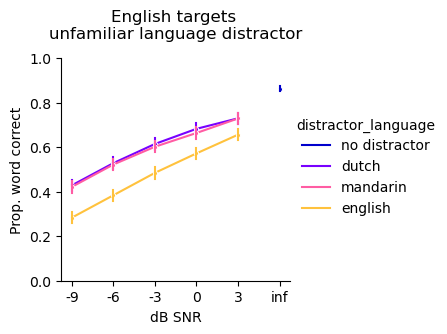

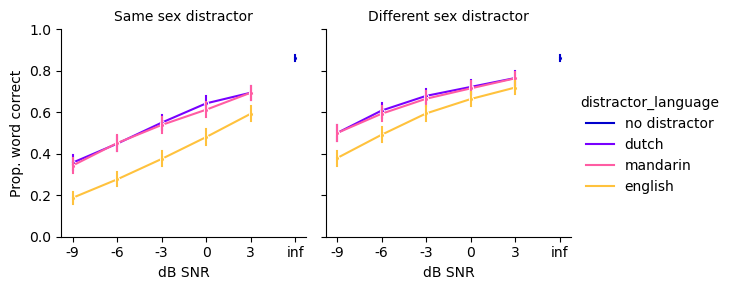

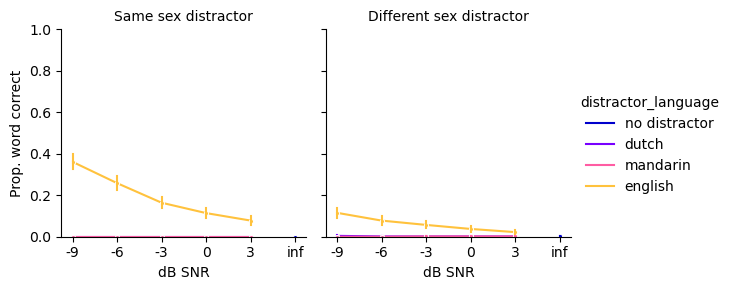

In [116]:
# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]

g = sns.relplot(data=all_model_results, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                # col='sex_cond',
                hue='distractor_language', hue_order = ['no distractor', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette='gnuplot2',
                height=3, aspect=1.1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = all_model_results.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())
plt.title('English targets \nunfamiliar language distractor', y=1.05)
plt.ylim(0,1)
# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=all_model_results, x='snr', y='accuracy', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                col='sex_cond',
                hue='distractor_language', hue_order = ['no distractor', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette='gnuplot2',
                height=3, aspect=1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = all_model_results.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)

# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]


# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=all_model_results, x='snr', y='confusions', # hue='gender_cond',
                # col_wrap=3,
                # hue='Distractor Sex', #
                col='sex_cond',
                hue='distractor_language', hue_order = ['no distractor', 'dutch', 'mandarin', 'english'],
                kind='line', marker='.',
                # color='k',
                palette='gnuplot2',
                height=3, aspect=1,
                err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. word correct")
g.set_titles("{col_name}")

# add xtick labels 
x_tick_locs = all_model_results.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)


___
### Sanity-check english portion to make sure accuracy and confusions similar to old data

In [87]:
melted_results = pd.melt(all_model_results[all_model_results.distractor_language == 'english'], id_vars=['snr', 'sex_cond'],
        value_vars=['accuracy', 'confusions'],
        value_name = 'hits',
        var_name = 'stream')

In [88]:
melted_results

,snr,sex_cond,stream,hits
0,-3,Same sex distractor,accuracy,0
1,-3,Different sex distractor,accuracy,0
2,-3,Same sex distractor,accuracy,1
3,-3,Different sex distractor,accuracy,1
4,-3,Different sex distractor,accuracy,1
...,...,...,...,...
14395,3,Same sex distractor,confusions,0
14396,3,Different sex distractor,confusions,0
14397,3,Same sex distractor,confusions,1
14398,3,Different sex distractor,confusions,0


(0.0, 1.0)

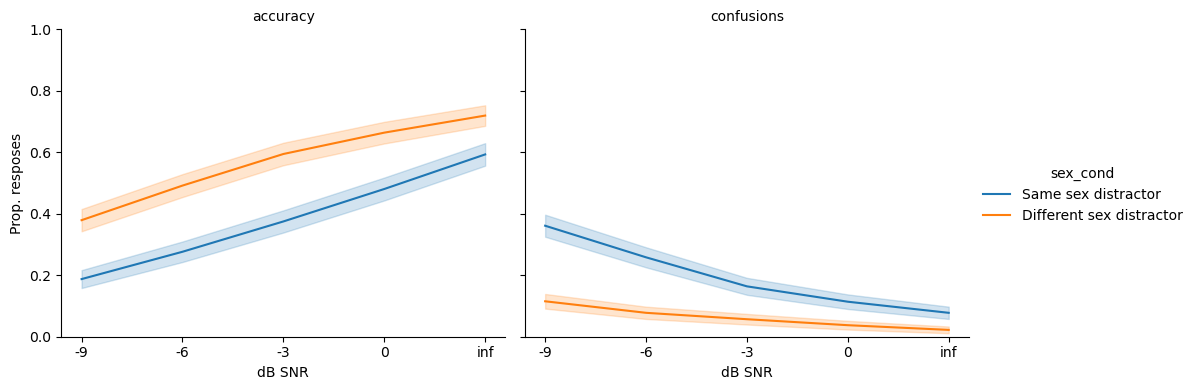

In [90]:
# results = all_results[all_results.snr.isin([0.25, 0.5,1,2])]


# group_order = [ f"Participants (N={part_summary_df.id_subject.nunique()})", 'Model']
# add markers to relplot
g = sns.relplot(data=melted_results, x='snr', y='hits', # hue='gender_cond',
                # col_wrap=3,
                hue='sex_cond', #
                col='stream',
                # style='Distractor Playback', style_order = ['Forward', 'Time Reversed'],
                kind='line', marker='',
                # color='k',
                height=4, aspect=1.25,
                # err_style='bars', 
                errorbar=('se', 2),)

# set labels 
g.set_axis_labels("dB SNR", "Prop. resposes")
g.set_titles("{col_name}")

# add xtick labels 

# add xtick labels 
x_tick_locs = melted_results.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)

# g.ax.set_xticks(ticks=results.snr.unique())
# g.set_xticklabels(results.snr.unique())

plt.ylim(0,1)
# plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
